# Climatology calculations

In [1]:
from earthkit import data as ekd
from earthkit import plots as ekp
from earthkit import transforms as ekt
from earthkit.transforms._tools import earthkit_remote_test_data_file

## Load test data

In this example we will use hourly ERA5 2m temperature point data (51.5˚ N, -1.0˚ E) for the years
1940 to 2025 as our physical data. This data was originally sourced from the
[ERA5 single levels time-series](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries)
collection in the CDS.

In [2]:
# Get some demonstration ERA5 data, this could be any url or path to an ERA5 grib or netCDF file.
remote_era5_file = earthkit_remote_test_data_file("ERA5-Reading-2m-temperature-1940-2025.nc")
era5_data = ekd.from_source("url", remote_era5_file)

# convert to xarray to save repeated conversion in further steps.
# As the data is small, we can compute it here, but for larger datasets you may want to delay this until later steps.
era5_xr = era5_data.to_xarray()
era5_xr

<xarray.Dataset> Size: 9MB
Dimensions:     (valid_time: 753888)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:...
    latitude    float64 8B ...
    longitude   float64 8B ...
Data variables:
    t2m         (valid_time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Calculate the climatologies

The climatology module offers a range of methods for calculating climatological statistics.
First we will use the basic methods to calculate climatological mean and standard-deviation
representative of the climatology period 1991-2020.

The `climatology_range` must provide the start and end date for the climatology period. 
It can be provided as date strings which are recognised by `xarray`,
for example `"YYYY"`, `"YYYY-MM"` and `"YYYY-MM-DD"`, or as a date objects such as
`datetime` objects or `numpy.datetime64` objects.

If the climatology range is not provided, then the whole time-period in the input data is used.

In [3]:
climatology_mean = ekt.climatology.mean(era5_xr, climatology_range=("1991", "2020"))
climatology_std = ekt.climatology.std(era5_xr, climatology_range=("1991", "2020"))
print(
    f"Climatology mean = {float(climatology_mean.t2m)}\n"
    f"Climatology standard deviation = {float(climatology_std.t2m)}"
)
climatology_mean

Climatology mean = 283.6854248046875
Climatology standard deviation = 5.9290385246276855


<xarray.Dataset> Size: 20B
Dimensions:    ()
Coordinates:
    latitude   float64 8B ...
    longitude  float64 8B ...
Data variables:
    t2m        float32 4B dask.array<chunksize=(), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

These functions are both wrappers of the base `ekt.climatology.reduce` function, where `how` is set
to `"mean"` and `"std"` respectively.

### Monthly climatology

It is possible to calculate monthly climatological statistics using the `monthly_reduce` function,
and a range of functions which wrap this.
The monthly climatologies provide a value of the requested statistic for each calendar month,
over the `climatology_range` period.

In the example below, we calculate the monthly mean for our 2m temperature data for the
`climatology_range` 1990 to 2020.
In the returned object the valid_time dimension has been replaced with a
`month` dimension with values `1` to `12` corresponding to months January to December.

In [4]:
climatology_monthly_mean = ekt.climatology.monthly_mean(era5_xr, climatology_range=("1991", "2020"))
climatology_monthly_mean

<xarray.Dataset> Size: 160B
Dimensions:    (month: 12)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    latitude   float64 8B ...
    longitude  float64 8B ...
Data variables:
    t2m        (month) float32 48B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

### Daily mean, min, max and standard deviation

We can perform similar calculations for the daily mean, minimum, maximum and standard deviation. This time the `valid_time` is replaced with a `dayofyear` dimension with values 1 to 366.

The 366th value is due to leap years, and it is the 366th value that is under-sampled (i.e. one value every 4 years).

In [5]:
climatology_daily_mean = ekt.climatology.daily_mean(era5_xr, climatology_range=("1991", "2020"))
climatology_daily_max = ekt.climatology.daily_max(era5_xr, climatology_range=("1991", "2020"))
climatology_daily_min = ekt.climatology.daily_min(era5_xr, climatology_range=("1991", "2020"))
climatology_daily_std = ekt.climatology.daily_std(era5_xr, climatology_range=("1991", "2020"))

climatology_daily_mean

<xarray.Dataset> Size: 4kB
Dimensions:    (dayofyear: 366)
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
    latitude   float64 8B ...
    longitude  float64 8B ...
Data variables:
    t2m        (dayofyear) float32 1kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

### Monthly quantiles

The API for climatology quantiles is slightly different, it requires an additional argument `q` which is a
list of the quantiles to return.
Additionally, the returned object has `quantiles` dimension which is for each of the quantiles returned.

In [6]:
climatology_monthly_quantiles = ekt.climatology.quantiles(
    era5_xr, [0.1, 0.5, 0.9], frequency="month", climatology_range=("1991", "2020")
)
climatology_monthly_quantiles

<xarray.Dataset> Size: 408B
Dimensions:   (quantile: 3, month: 12)
Coordinates:
  * quantile  (quantile) float64 24B 0.1 0.5 0.9
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    t2m       (quantile, month) float64 288B dask.array<chunksize=(1, 1), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Plot the output

First we plot the climatology data using an earthkit-plots `Climatology` figure.

/opt/homebrew/Caskroom/miniforge/base/envs/rtd-dev-env/lib/python3.12/site-packages/earthkit/plots/metadata/labels.py:278: UserWarning: No key "latitude" found in layer metadata.
  warnings.warn(f'No key "{attr}" found in layer metadata.')
/opt/homebrew/Caskroom/miniforge/base/envs/rtd-dev-env/lib/python3.12/site-packages/earthkit/plots/metadata/labels.py:278: UserWarning: No key "longitude" found in layer metadata.
  warnings.warn(f'No key "{attr}" found in layer metadata.')


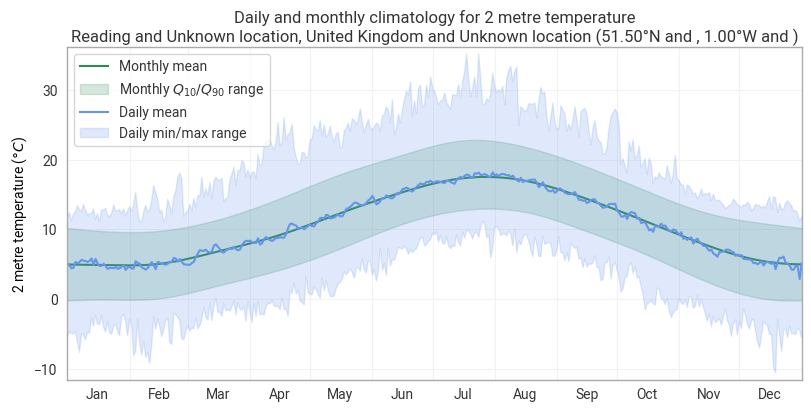

In [7]:
chart = ekp.Climatology(wrap_time=True)

chart.fix_y_units("celsius")

# Monthly mean + q10/q90 envelope
chart.line(climatology_monthly_mean, label="Monthly mean", color="seagreen", drawstyle="spline")
chart.fill_between(
    climatology_monthly_quantiles.sel(quantile=0.1),
    climatology_monthly_quantiles.sel(quantile=0.9),
    label="Monthly $Q_{10} / Q_{90}$ range",
    color="seagreen",
    drawstyle="spline",
)

# Daily mean + min/max envelope
chart.line(
    climatology_daily_mean,
    label="Daily mean",
    color="cornflowerblue",
)
chart.fill_between(
    climatology_daily_min,
    climatology_daily_max,
    label="Daily min/max range",
    color="cornflowerblue",
)

chart.title(
    "Daily and monthly climatology for {variable_name}\n{location:%c}, {location:%C} ({latitude:%Lt}, {longitude:%Ln})"
)
chart.xticks(frequency="M", period=True)
chart.ylabel()
chart.legend()
chart.show()

Now we add the climatology to the background of the Timeseries plot for the daily mean on the original `valid_time` dimension.
First we create the repeated climatology for the monthly quantiles, then we plot with `earthkit-plots`

In [8]:
latitude = 51.5
longitude = -1.0
sel_kwargs = {"latitude": latitude, "longitude": longitude, "method": "nearest"}

chart = ekp.TimeSeries()

# repeat_years tiles the month-dimensioned climatology across 2015–2017
# automatically — no dummy datetime coordinates needed.
chart.fill_between(
    climatology_monthly_quantiles.sel(**sel_kwargs, quantile=0.1),
    climatology_monthly_quantiles.sel(**sel_kwargs, quantile=0.9),
    repeat_years=range(2015, 2018),
    units="celsius",
    label="Monthly climatology ($Q_{10} / Q_{90}$ range)",
    color="seagreen",
    drawstyle="spline",
)

era5_daily_mean = ekt.temporal.daily_mean(era5_xr)
chart.line(era5_daily_mean.sel(**sel_kwargs), units="celsius", label="Daily mean ERA5 data", color="firebrick", lw=1)

chart.title(
    "Raw hourly data and repeated monthly climatology for {variable_name}\n"
    "{location:%c}, {location:%C} ({latitude:%Lt}, {longitude:%Ln})"
)

chart.xticks(frequency="6M", format="%B %Y")

chart.ylabel()
chart.legend()
chart.show()

KeyError: "'latitude' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'quantile': 3, 'month': 12})"